## Sections

- [Image classification](#Image-classification)
- [Generating and editing images](#Generating-and-editing-images)
- [Text generation](#Text-generation)
- [Image captioning](#Image-captioning)


# Image classification

In [1]:
import torchvision
from torchvision import models # predefined models

In [2]:
models.list_models() # list of predefined models

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [3]:
alexnet = models.AlexNet()

## Vision Transformer
**A Vision Transformer (ViT)** is an adaptation of the transformer architecture, originally designed for language, to process and analyze images. Instead of treating images as grids of pixels through convolutional layers, **ViTs** divide images into small patches, convert them into sequences, and apply attention mechanisms to understand relationships between different parts of the image. **ViTs** have achieved competitive or superior performance compared to traditional convolutional neural networks on many computer vision tasks.

In [4]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

In [5]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [6]:
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(256),         # scale the input image to 256 × 256
    transforms.CenterCrop(224),     # crop the image to 224 × 224 around the center
    transforms.ToTensor(),          # transform it to a tensor
    transforms.Normalize(           # normalize its RGB components so that they have defined means and standard deviations
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
from PIL import Image
img = Image.open("../data/p1ch2/bobby.jpg")

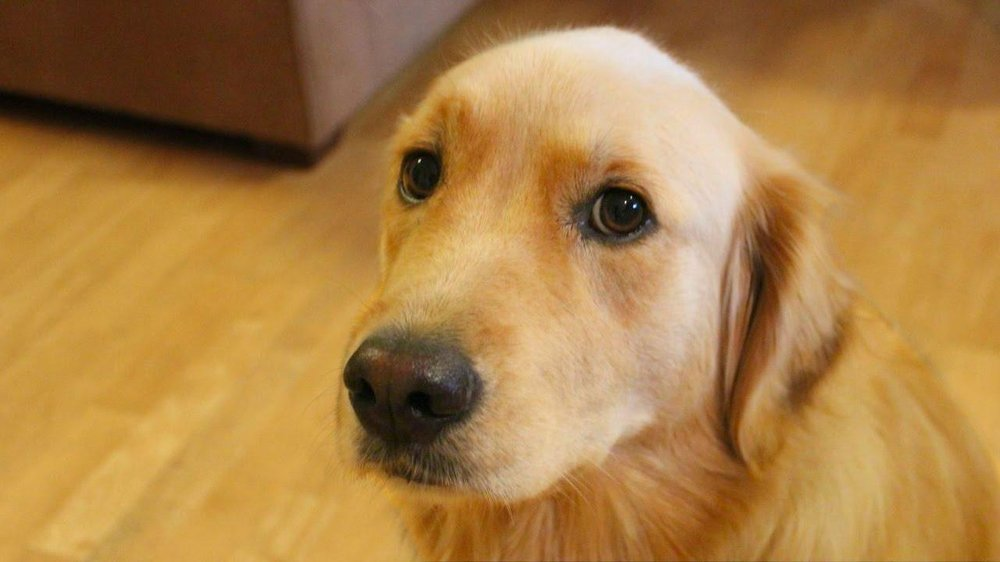

In [8]:
img # show in Jupyter Notebook

In [9]:
#img.show() # pop up a window with a viewer, to see the image

In [10]:
img_t = preprocess(img)

In [11]:
img_t

tensor([[[-0.6281, -0.6452, -0.6623,  ...,  0.0056, -0.0287, -0.0629],
         [-0.7137, -0.6965, -0.6965,  ...,  0.0227,  0.0227,  0.0056],
         [-0.7137, -0.7137, -0.7137,  ...,  0.0398,  0.0741,  0.0569],
         ...,
         [ 1.4440,  1.4269,  1.4783,  ...,  0.6049,  0.6221,  0.6906],
         [ 1.4269,  1.4440,  1.4783,  ...,  0.6906,  0.6734,  0.7077],
         [ 1.4612,  1.4783,  1.5297,  ...,  0.6906,  0.7248,  0.7591]],

        [[-1.2829, -1.2829, -1.2829,  ..., -0.6352, -0.6702, -0.7052],
         [-1.2654, -1.2654, -1.2654,  ..., -0.6176, -0.6527, -0.7052],
         [-1.2479, -1.2479, -1.2654,  ..., -0.6176, -0.6001, -0.6527],
         ...,
         [ 0.7829,  0.8004,  0.8704,  ..., -0.2850, -0.2675, -0.2150],
         [ 0.7654,  0.8354,  0.9055,  ..., -0.2150, -0.2150, -0.1625],
         [ 0.8004,  0.8529,  0.9230,  ..., -0.1800, -0.1275, -0.0749]],

        [[-1.4907, -1.4559, -1.4210,  ..., -1.0376, -1.0898, -1.1421],
         [-1.5081, -1.4559, -1.4210,  ..., -1

In [12]:
import torch
batch_t = torch.unsqueeze(img_t, 0)

In [13]:
vit.eval() # put the network in eval mode (ready for run on new data)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

In [14]:
out = vit(batch_t)
out

tensor([[-2.0532e-01, -6.0847e-02, -5.4070e-02,  1.3571e-01,  5.3633e-02,
         -4.3016e-02,  1.0885e-01, -4.5990e-02, -2.2472e-01,  3.2890e-01,
         -8.1749e-02, -3.5140e-01, -6.1703e-02,  3.4161e-01, -1.3901e-01,
          1.8390e-01, -9.3056e-02, -9.1409e-02,  2.5858e-01,  1.3135e-02,
         -1.0241e-02,  6.3711e-02,  3.4067e-01,  5.7044e-01,  2.7524e-01,
          1.5958e-01,  4.0679e-01,  1.4981e-01, -8.6190e-02,  2.9268e-01,
          3.9628e-01,  5.6545e-01,  4.7991e-01,  5.5809e-01,  2.9767e-01,
          5.0092e-01, -1.0148e-02, -1.5361e-01,  2.5551e-01, -5.5136e-02,
          5.2890e-01, -3.8312e-01,  1.8834e-01,  2.6361e-01, -3.0182e-02,
          2.8542e-01,  3.1363e-01,  2.7279e-01, -1.9818e-02,  2.2100e-01,
         -2.5667e-01,  1.4222e-01,  4.3315e-02,  1.6771e-02, -1.0518e-01,
          6.4253e-01, -1.6882e-01,  2.6988e-01,  4.2442e-01,  2.0398e-01,
         -3.1416e-01, -2.1608e-01,  2.8850e-01,  2.2958e-01,  2.5203e-01,
         -2.5002e-01,  1.9824e-01,  7.

In [15]:
len(out[0]) # vector of 1,000 scores, one per ImageNet class

1000

In [16]:
with open('../data/p1ch2/imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]

In [17]:
labels

['tench, Tinca tinca',
 'goldfish, Carassius auratus',
 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 'tiger shark, Galeocerdo cuvieri',
 'hammerhead, hammerhead shark',
 'electric ray, crampfish, numbfish, torpedo',
 'stingray',
 'cock',
 'hen',
 'ostrich, Struthio camelus',
 'brambling, Fringilla montifringilla',
 'goldfinch, Carduelis carduelis',
 'house finch, linnet, Carpodacus mexicanus',
 'junco, snowbird',
 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 'robin, American robin, Turdus migratorius',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel, dipper',
 'kite',
 'bald eagle, American eagle, Haliaeetus leucocephalus',
 'vulture',
 'great grey owl, great gray owl, Strix nebulosa',
 'European fire salamander, Salamandra salamandra',
 'common newt, Triturus vulgaris',
 'eft',
 'spotted salamander, Ambystoma maculatum',
 'axolotl, mud puppy, Ambystoma mexicanum',
 'bullfrog, Rana catesbeiana',
 'tree frog, tree-f

In [18]:
len(labels)

1000

In [19]:
_, index = torch.max(out, 1) # find the maximum score index in the out tensor

In [20]:
index

tensor([207])

In [21]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100 # softmax: normalize our outputs to the range [0, 1] and divide by the sum
labels[index.item()], percentage[index.item()].item()

('golden retriever', 86.4409408569336)

In [22]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('golden retriever', 86.4409408569336),
 ('Labrador retriever', 0.354882150888443),
 ('tennis ball', 0.32364413142204285),
 ('cocker spaniel, English cocker spaniel, cocker', 0.15340165793895721),
 ('Airedale, Airedale terrier', 0.14846619963645935)]

# Generating and editing images

In [1]:
from diffusers import StableDiffusionInpaintPipeline
import torch
import PIL.Image as Image

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(device)
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    # torch_dtype=torch.float16
    torch_dtype=torch.float32
)
# ).to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

In [2]:
pipe

StableDiffusionInpaintPipeline {
  "_class_name": "StableDiffusionInpaintPipeline",
  "_diffusers_version": "0.39.0",
  "_name_or_path": "sd2-community/stable-diffusion-2-inpainting",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

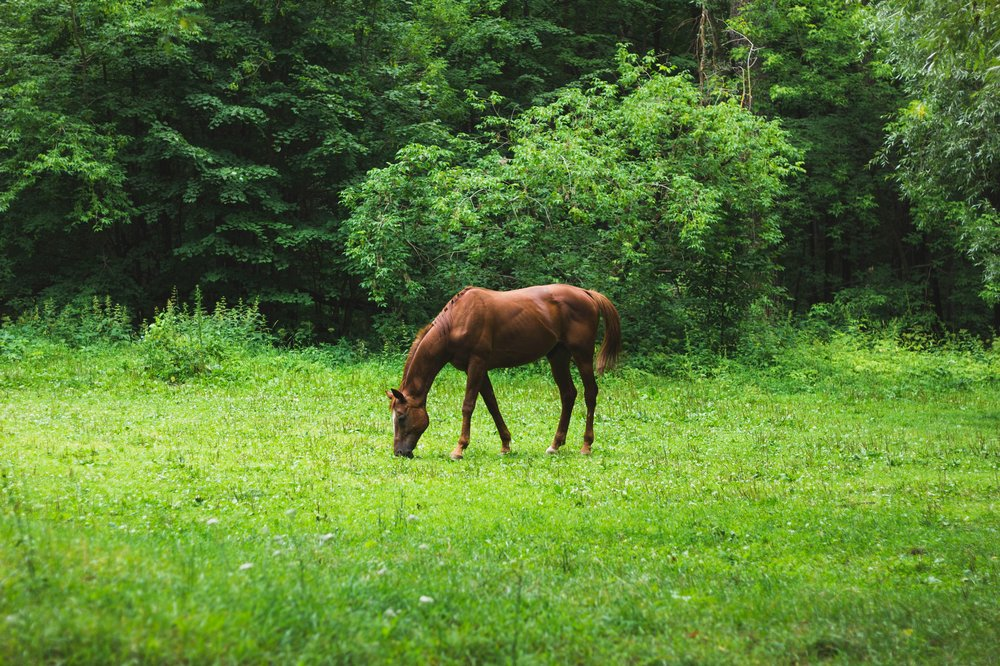

In [3]:
img = Image.open("../data/p1ch2/horse.jpg")
img

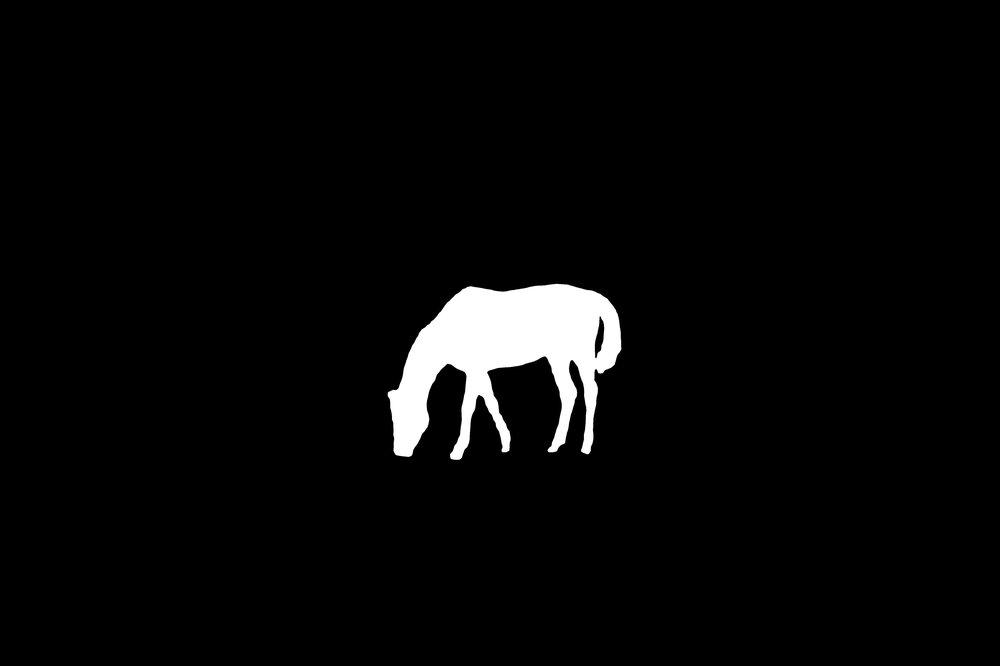

In [4]:
mask_img = Image.open("../data/p1ch2/horse_mask.jpg")
mask_img

In [5]:
prompt = ("a zebra replacing the original horse, same pose, same lighting, background unchanged")
negative = "distorted background, blurry, text, watermark"
out = pipe(
    prompt=prompt,
    image=img,
    mask_image=mask_img,
    negative_prompt=negative,
    guidance_scale=7.5,
    strength=0.8,
    # generator=torch.Generator(device).manual_seed(42)
    generator=torch.Generator().manual_seed(42)
)

  0%|          | 0/40 [00:00<?, ?it/s]

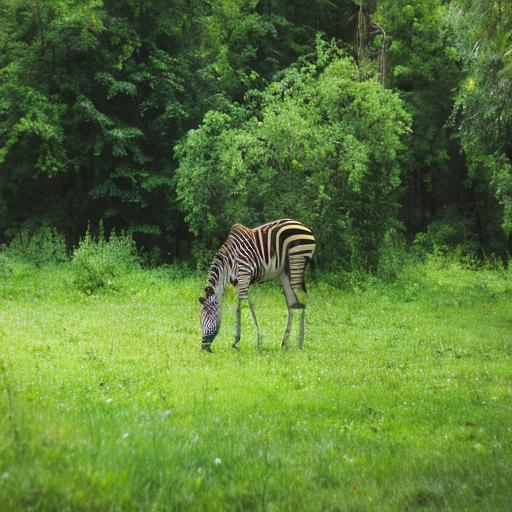

In [6]:
out.images[0]

# Text generation

In [2]:
from transformers import pipeline, GenerationConfig

generator = pipeline('text-generation', model='gpt2', device=-1)  # use cpu
gen_config = GenerationConfig(
    max_length=10,
    max_new_tokens=None,
)
generator("AI models are so smart they can replace my", generation_config=gen_config)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[{'generated_text': 'AI models are so smart they can replace my car'}]

# Image captioning

In [2]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

In [3]:
def annotate_image(image: Image) -> None:
    display(image)
    inputs = processor(image, return_tensors="pt")
    out = model.generate(**inputs, max_new_tokens=50)
    print(processor.decode(out[0], skip_special_tokens=True))

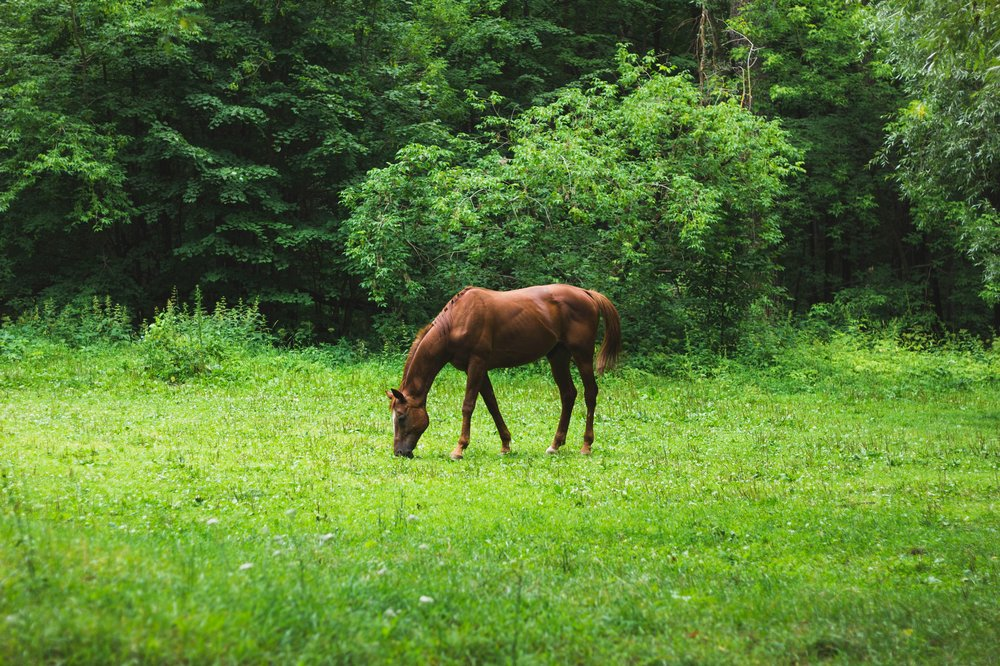

there is a brown horse grazing in a field of green grass


In [4]:
annotate_image(Image.open("../data/p1ch2/horse.jpg"))